# Oppimisprojekti 3, osa 1: tekstigeneraattori transformerilla

Tässä notebookissa koulutetaan pieni decoder-tyyppinen transformer-malli tuottamaan Kalevalan tyylistä tekstiä. Tavoitteena on ymmärtää käytännössä, miten transformer oppii tekstiaineistosta seuraavan tokenin ennustamista.

**Tekoälyn käyttö:** Tekoälyä käytettiin apuna notebookin rakenteen suunnittelussa, koodin virheiden korjaamisessa ja raporttitekstin muotoilussa.


## Raportti

### Valittu tekstiaineisto

Aineistona käytettiin `kalevala_puhdas.txt`-tiedostoa. Tiedoston koko on noin 591 kt, joten se täyttää tehtävän vähintään 100 kt vaatimuksen. Kalevala on hyvä valinta, koska se on tekijänoikeuksista vapaa suomenkielinen klassikko, jonka tyyli on selvästi tunnistettava: runomitta, toistuvat henkilönimet ja vanhahtava sanasto näkyvät mallin tuottamassa tekstissä.

### Mallin rakenne ja tulokset

Käytetty malli oli pieni decoder-only transformer:

| Ominaisuus | Arvo |
|---|---:|
| Tokenisointi | SentencePiece BPE |
| Sanaston koko | 4000 |
| Sekvenssin pituus | 64 tokenia |
| Embedding-koko | 96 |
| Attention-päitä | 3 |
| Transformer-blokkeja | 2 |
| Feed-forward-koko | 192 |
| Parametreja | 921 568 |
| Koulutusasetukset | `fast`, 3 epochia, batch size 64 |
| Validointitulos | loss noin 3.58 ja accuracy noin 0.27 validointijoukon 2000 ensimmäisellä näytteellä |

Tulos ei ole täydellistä suomea, mutta se oppii Kalevalalle tyypillisiä piirteitä: nimiä, runomaista rytmiä, vanhahtavia sanamuotoja ja toistuvia lauserakenteita.

### Generoidut esimerkit

| Aloitusteksti | Lämpötila | Generoitu teksti |
|---|---:|---|
| Vaka vanha Väinämöinen | 0.4 | Vaka vanha Väinämöinen, kolmas, läksi, ei tuopit, takoja iän-ikuinen, tuon sanoiksi virkki: "Oi sie vanha Väinämöinen! Jo nyt, kantajani! Sitä itken, kuta, kantajani! "Kukas, tuotanehe, jospa sinun Manalle saisi, jost, kuule minua, ei ole tässä ennen yön tytti, kun sauvoani! Kunneasi, kuin sanelen, tuoman vil |
| Vaka vanha Väinämöinen | 0.8 | Vaka vanha Väinämöinen, kuni käärmehen elämätöintä, kahta kämmenen ilta, emon impenätärhen." Muuttuuli veistämäkeä, sanan virkkoi, noin nimesi: "Te kerä pese. Jo nyt hiet, luikun viltin alla poikki venettä; muua, kaunis,kanen varte ennen minunki virren pistelevi: ei nuoraha. Tuhannut tehtän |
| Vaka vanha Väinämöinen | 1.0 | Vaka vanha Väinämöinen, kuta aallon vastaeli, paksu, ilman ajassa. "Niinpä täynnä nappa katoovat, puheli: juosnut lähtemästä Lemminkäistä, vasta on kesken vaahtile nyt tänne tarvittaissa. Untamo ajattelevi, nahisi, mukkahanonne läksit, urohot tällä inhalla. Siinä impi, viikon kulta unteltu! Itsensä paatonensansa, impi mennä, hopeansa, na |
| Vaka vanha Väinämöinen | 1.3 | Vaka vanha Väinämöinen! Sitte hepoarjet makstele! Aja Arvelee, päätä noien harkka aamauta luik Väinölähän sopy kyutti, kirjokansiitejillätusten viilrä, sulhot, naurantahan. Untamo uhreheämättä luo kaarta Hiien hevosen päätä kylpemin heittätaroi siellä viisi vaskisille kolisellen, hiiltustetahan, vielä muistanana väsynta. Näki juokse halki kaikehen |
| Mieleni minun tekevi | 0.4 | Mieleni minun tekevi, alle, kymmi, selässä, pää hopea huhat härän sarvena, ve'en kalmahan. "Kun ei ole iso elossa, se on tuo minua, veri, kun ei tuleva, jospa saisinpa sauvoani, jos on uusi ottaminen, joka soimat, kunne käsken, kuolkahan Tapiolan ulkona sauvoani, joka soi |
| Mieleni minun tekevi | 0.8 | Mieleni minun tekevi, ruoskan, taljoilleni." Ajoi pur käessä. Lausui lapsi, tuosta tuon sanoiksi virkki: "Ken saunastansa, tietäjä iän-ikuinen! Kääntämme, tuotanehe, joit! Jo nyt sopiva! Istuki juominkihin! Jo olen on surmata, on mull' on hartioitse ilokä, viereit! "Mene! "Suotta, |
| Mieleni minun tekevi | 1.0 | Mieleni minun tekevi, kova onni, tuolta, laks'akas tässä sureksi, joka kisko! Sitte sinne saatuansa, tunsitta, hivusgon tieltä sarven, vehnäsi itkeä, lehot leikki, kohenna, mäelle, tämän ajohisevistä-jele, armaiseni, metsän korjiä Tuonelan joesta, harmiele, polvea, silmät kättä, joka nuorin pohjasen |
| Mieleni minun tekevi | 1.3 | Mieleni minun tekevi, laula kulahilla, kuu saane rannumahan. Jo olen aianisien käs tiellä luona soittoapsankehen nukvät karmmelmaista opporea kokosi, kivilta kylehjanime meren lietehessä kulta vyöttä kohin artit rekosehensa! Hyvä on läksi avissani joutuvi kokko matkoa vähäisen, yksi sanua piikaset, satun ollaksensaelevi myöten keskimä |
| Pohjan neito | 0.4 | Pohjan neito, haapa, kaota, hope'ita, hope'ita. "Kun ei ollut, en, mies pahoiksi, kun saisin naurun-ikuinen! Tulin tuulen tuoa, jospa parasta, kuin on muua, emolle, ei tuotanehe, en mä tuostana totelle, kun sait' on tuohon tuotanehe, vääjänne väheäkänä, oman linnun |
| Pohjan neito | 0.8 | Pohjan neito, karja, entisille hevolla, kiikuiset, jospa, kuin sanelen, impenä rakenna, pää Kalman kartanosta! "Kun karja korvinpa, emon kaune, katko itseni luppa, käet kaikki Kalman kartanossa, hope'isen silmät, saatat, maan alimansa. Lyhy, rapoa parata putoa tanterilla! |
| Pohjan neito | 1.0 | Pohjan neito, pää purren, tah palavistuuli puol'ama, onko kansa, metsän omin kätösi tulehen, lohi syömähän. Tun kovahan raiat maille. "Sanotin mitä parempanaki tänne tuop' onpa kauhean, luotolla katala, on maalla mahitsistävät paian palkan, vesa venoista, välitke kullaista kuvoasijani |
| Pohjan neito | 1.3 | Pohjan neito ison kannan hun, sorikö terista maa entisen pitäisi, unelta elä reysi." Sanoi vanha Väinämöinen: "Mehiläinen olkapäilla utuisen iso toisen, kummassa katosi, rakki putosi pu miekkouet saatanehe. Sanan virkki neuvehen mitätty eil, Kullerviket yöt tuljaksi tulen kalaota sivutsellest, halki kämmenissä keräli rannahat satah Neit |

### Havainnot lämpötila-arvoista

Pienellä lämpötilalla, esimerkiksi `0.4`, teksti on varovaisempaa ja toisteisempää. Se pysyy paremmin Kalevalan sanastossa, mutta alkaa helposti kierrättää samoja ilmauksia. Keskitasolla `0.8` ja `1.0` tulos on vaihtelevampaa: mukana on selvästi Kalevalan tyyliä, mutta myös rikkonaisia tai outoja sanayhdistelmiä. Suurella lämpötilalla `1.3` teksti muuttuu luovemmaksi ja sekavammaksi, jolloin sanojen taivutus ja lauserakenne hajoavat useammin.

### Hyperparametrien vaikutus

Tässä ajossa käytettiin tarkoituksella pientä mallia, jotta koulutus pysyy mahdollisena tavallisella koneella. Pieni embedding-koko, vähäinen blokkien määrä ja lyhyt sekvenssi nopeuttavat koulutusta, mutta rajoittavat mallin kykyä muodostaa pitkiä johdonmukaisia kokonaisuuksia. Nopeus vastaan laatu -kokeilu näkyy tässä erityisesti siinä, että `fast`-asetus koulutettiin loppuun ja sen tuloksia analysoitiin. Maksimilaatua varten notebookissa on mukana suurempi `quality`-asetus, jossa embedding-koko on 192 ja transformer-blokkeja on 4; sitä ei ajettu loppuun palautusversiossa, koska koulutusaika ja muistinkulutus kasvaisivat selvästi. Tämän perusteella suurempi malli todennäköisesti oppisi paremmin pidempiä riippuvuuksia ja tuottaisi sujuvampaa tekstiä, mutta vaatisi enemmän laskentatehoa.

### Miksi transformer-mallin kouluttaminen alusta alkaen on hidasta?

Alusta koulutettu malli ei tiedä valmiiksi mitään suomen kielestä, Kalevalan sanastosta tai tekstin rakenteesta. Se joutuu oppimaan kaiken tokenien välisistä tilastollisista suhteista. Transformerissa attention vertaa sekvenssin tokeneita toisiinsa, joten pidempi konteksti lisää laskentaa. Lisäksi suurempi sanasto, suuremmat embeddingit ja useammat kerrokset kasvattavat parametrimäärää nopeasti. Esikoulutetut mallit ovat arvokkaita juuri siksi, että yleinen kielitaito on opittu etukäteen paljon suuremmalla aineistolla ja laskentateholla.

In [1]:
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm
import keras
from keras import layers

np.random.seed(42)
print("Keras:", keras.__version__)
print("Backend:", keras.config.backend())

Keras: 3.14.1
Backend: tensorflow


In [2]:
DATA_PATH = Path("kalevala_puhdas.txt")
assert DATA_PATH.exists(), f"Tiedostoa ei löydy: {DATA_PATH.resolve()}"

text = DATA_PATH.read_text(encoding="utf-8-sig")
print(f"Merkkejä: {len(text):,}")
print(f"Tavuja: {DATA_PATH.stat().st_size:,}")
print(text[:500])

Merkkejä: 545,594
Tavuja: 590,912
Ensimmäinen runo


Mieleni minun tekevi,
aivoni ajattelevi
lähteäni laulamahan,
saa'ani sanelemahan,
sukuvirttä suoltamahan,
lajivirttä laulamahan.
Sanat suussani sulavat,
puhe'et putoelevat,
kielelleni kerkiävät,
hampahilleni hajoovat.
Veli kulta, veikkoseni,
kaunis kasvinkumppalini!
Lähe nyt kanssa laulamahan,
saa kera sanelemahan
yhtehen yhyttyämme,
kahta'alta käytyämme!
Harvoin yhtehen yhymme,
saamme toinen toisihimme
näillä raukoilla rajoilla,
poloisilla Pohjan mailla.
Lyökämme käsi kätehen


## Tokenisointi

Käytän SentencePiece BPE -tokenisointia. Se jakaa sanat osiin, jolloin malli pystyy käsittelemään myös harvinaisia suomen taivutusmuotoja ilman valtavaa sanastoa.

In [3]:
VOCAB_SIZE = 4000
MODEL_PREFIX = "kalevala_sp_project"
TOKENIZER_MODEL = Path(f"{MODEL_PREFIX}.model")

if not TOKENIZER_MODEL.exists():
    tmp = Path("kalevala_sentencepiece_input.txt")
    tmp.write_text(text, encoding="utf-8")
    spm.SentencePieceTrainer.train(
        input=str(tmp),
        model_prefix=MODEL_PREFIX,
        vocab_size=VOCAB_SIZE,
        character_coverage=1.0,
        model_type="bpe",
        pad_id=0,
        unk_id=1,
        bos_id=2,
        eos_id=3,
    )

sp = spm.SentencePieceProcessor()
sp.load(str(TOKENIZER_MODEL))
print("Sanaston koko:", sp.get_piece_size())
print(sp.encode_as_pieces("Vaka vanha Väinämöinen"))

Sanaston koko: 4000
['▁Vaka', '▁vanha', '▁Väinämöinen']


In [4]:
SEQ_LENGTH = 64
STRIDE = 2
MAX_SEQUENCES = 60000

ids = np.array(sp.encode_as_ids(text), dtype=np.int32)
print("Tokeneita:", len(ids))

windows = []
for start in range(0, len(ids) - SEQ_LENGTH - 1, STRIDE):
    windows.append(ids[start:start + SEQ_LENGTH + 1])
    if MAX_SEQUENCES and len(windows) >= MAX_SEQUENCES:
        break

windows = np.array(windows, dtype=np.int32)
inputs = windows[:, :-1]
targets = windows[:, 1:]

rng = np.random.default_rng(42)
indices = rng.permutation(len(inputs))
split = int(0.85 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

train_inputs, train_targets = inputs[train_idx], targets[train_idx]
val_inputs, val_targets = inputs[val_idx], targets[val_idx]

print("Opetusdata:", train_inputs.shape, train_targets.shape)
print("Validointi:", val_inputs.shape, val_targets.shape)

Tokeneita: 144826
Opetusdata: (51000, 64) (51000, 64)
Validointi: (9000, 64) (9000, 64)


## Malli

Malli on decoder-only transformer: se näkee vain aiemmat tokenit causal maskin avulla. Tämä vastaa tekstigeneraattorin perusideaa, jossa seuraava token ennustetaan aiemman kontekstin perusteella.

In [5]:
def transformer_block(x, embed_dim, num_heads, ff_dim, dropout=0.1, name="block"):
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout,
        name=f"{name}_attention",
    )(x, x, use_causal_mask=True)
    x = layers.Add(name=f"{name}_attn_residual")([x, attn])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_attn_norm")(x)

    ff = keras.Sequential([
        layers.Dense(ff_dim, activation="gelu"),
        layers.Dropout(dropout),
        layers.Dense(embed_dim),
    ], name=f"{name}_ffn")(x)
    x = layers.Add(name=f"{name}_ffn_residual")([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ffn_norm")(x)
    return x


def build_model(vocab_size, seq_length, embed_dim=128, num_heads=4, num_layers=2, ff_dim=256, dropout=0.1):
    token_ids = keras.Input(shape=(seq_length,), dtype="int32", name="token_ids")
    positions = keras.ops.expand_dims(keras.ops.arange(0, seq_length), axis=0)

    token_embedding = layers.Embedding(vocab_size, embed_dim, name="token_embedding")(token_ids)
    position_embedding = layers.Embedding(seq_length, embed_dim, name="position_embedding")(positions)
    x = layers.Add(name="token_plus_position")([token_embedding, position_embedding])
    x = layers.Dropout(dropout)(x)

    for i in range(num_layers):
        x = transformer_block(x, embed_dim, num_heads, ff_dim, dropout, name=f"block_{i+1}")

    logits = layers.Dense(vocab_size, name="token_logits")(x)
    model = keras.Model(token_ids, logits, name="kalevala_decoder_transformer")
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )
    return model

configs = {
    "fast": dict(embed_dim=96, num_heads=3, num_layers=2, ff_dim=192, dropout=0.1, batch_size=64, epochs=3),
    "quality": dict(embed_dim=192, num_heads=4, num_layers=4, ff_dim=384, dropout=0.1, batch_size=48, epochs=5),
}

ACTIVE_CONFIG = "fast"
params = configs[ACTIVE_CONFIG]
model = build_model(sp.get_piece_size(), SEQ_LENGTH, **{k: params[k] for k in ["embed_dim", "num_heads", "num_layers", "ff_dim", "dropout"]})
model.summary()
print("Parametreja yhteensä:", f"{model.count_params():,}")

Model: "kalevala_decoder_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, 64, 96)    │    384,000 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_plus_position │ (1, 64, 96)       │          0 │ token_embedding[… │
│ (Add)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (1, 64, 96)       │          0 │ token_plus_posit… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_attention   │ (1, 64, 96)       │     37,248 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_attn_resid… │ (1, 64, 96)       │          0 │ dropout[0][0],    │
│ (Add)               │                   │            │ block_1_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_attn_norm   │ (1, 64, 96)       │        192 │ block_1_attn_res… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_ffn         │ (1, 64, 96)       │     37,152 │ block_1_attn_nor… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_ffn_residu… │ (1, 64, 96)       │          0 │ block_1_attn_nor… │
│ (Add)               │                   │            │ block_1_ffn[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_ffn_norm    │ (1, 64, 96)       │        192 │ block_1_ffn_resi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_attention   │ (1, 64, 96)       │     37,248 │ block_1_ffn_norm… │
│ (MultiHeadAttentio… │                   │            │ block_1_ffn_norm… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_attn_resid… │ (1, 64, 96)       │          0 │ block_1_ffn_norm… │
│ (Add)               │                   │            │ block_2_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_attn_norm   │ (1, 64, 96)       │        192 │ block_2_attn_res… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_ffn         │ (1, 64, 96)       │     37,152 │ block_2_attn_nor… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_ffn_residu… │ (1, 64, 96)       │          0 │ block_2_attn_nor… │
│ (Add)               │                   │            │ block_2_ffn[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_2_ffn_norm    │ (1, 64, 96)       │        192 │ block_2_ffn_resi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_logits        │ (1, 64, 4000)     │    388,000 │ block_2_ffn_norm… │
│ (Dense)             │                   │            │                 

 Total params: 921,568 (3.52 MB)

 Trainable params: 921,568 (3.52 MB)

 Non-trainable params: 0 (0.00 B)

Parametreja yhteensä: 921,568


In [6]:
start_time = time.perf_counter()
history = model.fit(
    train_inputs,
    train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=params["batch_size"],
    epochs=params["epochs"],
)
training_seconds = time.perf_counter() - start_time
print(f"Koulutusaika: {training_seconds:.1f} s")

Epoch 1/3
797/797 ━━━━━━━━━━━━━━━━━━━━ 174s 211ms/step - accuracy: 0.1572 - loss: 6.0345 - val_accuracy: 0.2096 - val_loss: 4.9582
Epoch 2/3
797/797 ━━━━━━━━━━━━━━━━━━━━ 165s 206ms/step - accuracy: 0.2196 - loss: 4.5564 - val_accuracy: 0.2364 - val_loss: 4.0798
Epoch 3/3
797/797 ━━━━━━━━━━━━━━━━━━━━ 149s 187ms/step - accuracy: 0.2410 - loss: 3.9449 - val_accuracy: 0.2701 - val_loss: 3.5775
Koulutusaika: 487.8 s


,accuracy,loss,val_accuracy,val_loss,epoch
0,0.157185,6.034475,0.209554,4.958248,1
1,0.219575,4.556393,0.236418,4.079802,2
2,0.241044,3.944921,0.270106,3.577519,3


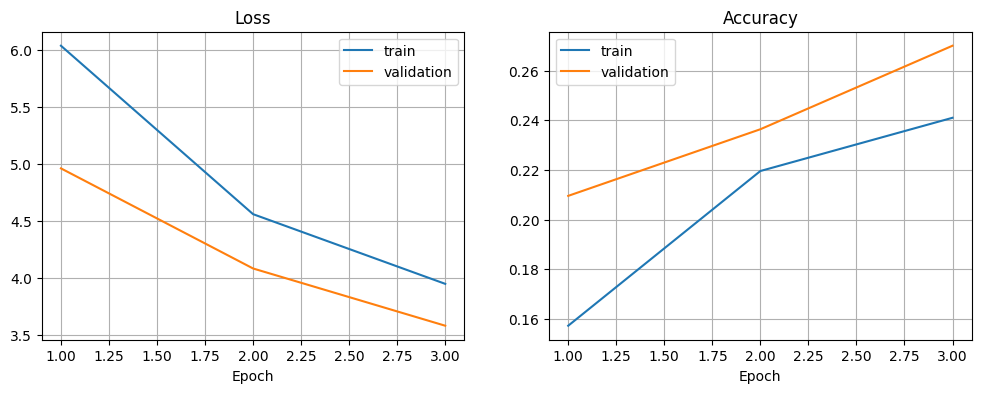

In [7]:
history_df = pd.DataFrame(history.history)
history_df["epoch"] = np.arange(1, len(history_df) + 1)
display(history_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["accuracy"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].grid(True)
axes[1].legend()
plt.show()

## Tekstin generointi eri lämpötiloilla

Lämpötila muuttaa seuraavan tokenin todennäköisyysjakaumaa. Pieni arvo tekee tekstistä varovaisempaa ja toisteisempaa, suuri arvo luovempaa mutta myös sekavampaa.

In [8]:
def sample_from_logits(logits, temperature=1.0):
    temperature = max(float(temperature), 1e-5)
    logits = logits / temperature
    logits = logits - np.max(logits)
    probs = np.exp(logits)
    probs = probs / probs.sum()
    return int(np.random.choice(len(probs), p=probs))


def generate_text(model, sp, prompt, num_tokens=120, temperature=1.0, seq_length=SEQ_LENGTH):
    context = sp.encode_as_ids(prompt)
    generated = list(context)

    for _ in range(num_tokens):
        window = generated[-seq_length:]
        if len(window) < seq_length:
            window = [sp.pad_id()] * (seq_length - len(window)) + window
        x = np.array([window], dtype=np.int32)
        logits = model.predict(x, verbose=0)[0, -1]
        next_id = sample_from_logits(logits, temperature)
        generated.append(next_id)

    return sp.decode(generated)

prompts = ["Vaka vanha Väinämöinen", "Mieleni minun tekevi", "Pohjan neito"]
temperatures = [0.4, 0.8, 1.0, 1.3]

rows = []
for prompt in prompts:
    for temp in temperatures:
        rows.append({
            "prompt": prompt,
            "temperature": temp,
            "generated_text": generate_text(model, sp, prompt, temperature=temp),
        })

generated_df = pd.DataFrame(rows)
display(generated_df)

,prompt,temperature,generated_text
0,Vaka vanha Väinämöinen,0.4,"Vaka vanha Väinämöinen, seitsemän siniotella, ..."
1,Vaka vanha Väinämöinen,0.8,"Vaka vanha Väinämöinen, pyhän virran soitannik..."
2,Vaka vanha Väinämöinen,1.0,"Vaka vanha Väinämöinen! Hyvä yhtehen paran, va..."
3,Vaka vanha Väinämöinen,1.3,Vaka vanha Väinämöinen otti pojan pesänsä: kir...
4,Mieleni minun tekevi,0.4,"Mieleni minun tekevi. ""Lauloista, penne' on su..."
5,Mieleni minun tekevi,0.8,"Mieleni minun tekevi, enemminki lahoa, kultala..."
6,Mieleni minun tekevi,1.0,"Mieleni minun tekevi. ""Kun et itke! Kivi on se..."
7,Mieleni minun tekevi,1.3,Mieleni minun tekevi taran viereisiltansa pä'a...
8,Pohjan neito,0.4,"Pohjan neitosella, seivarahutta, korjoilla. ""K..."
9,Pohjan neito,0.8,"Pohjan neito, lakoa! Mitä huoli, valjaluelin. ..."


In [9]:
MODEL_PATH = Path(f"kalevala_transformer_{ACTIVE_CONFIG}.keras")
model.save(MODEL_PATH)
print("Tallennettu:", MODEL_PATH.resolve())

Tallennettu: D:\Transformer-mallit\kalevala_transformer_fast.keras


In [10]:
loaded_model = keras.models.load_model("kalevala_transformer_fast.keras")
loaded_model.evaluate(val_inputs[:2000], val_targets[:2000], batch_size=64)

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.2707 - loss: 3.5806


[3.5806455612182617, 0.27073436975479126]